# Notebook 9 — Random Forest

A single Decision Tree can be a bit unpredictable — small changes in the
data can give a very different tree. A **Random Forest** fixes this by
training *many* trees and combining their answers.

We'll use the same retail dataset again, and compare a single tree against
a whole forest.

### Setup

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

### Load the Data

Same retail data, with the `HighValue` label (1 = above median order
price, 0 = below).

In [5]:
data = pd.read_csv("data.csv", encoding="latin1")
data = data[(data["Quantity"] > 0) & (data["UnitPrice"] > 0)]
data["TotalPrice"] = data["Quantity"] * data["UnitPrice"]
data = data.sample(200, random_state=1).reset_index(drop=True)
median_price = data["TotalPrice"].median()
data["HighValue"] = (data["TotalPrice"] > median_price).astype(int)
X = data[["Quantity", "UnitPrice"]]
y = data["HighValue"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
data[["Quantity", "UnitPrice", "HighValue"]].head()

,Quantity,UnitPrice,HighValue
0,6,7.95,1
1,2,1.25,0
2,3,1.25,0
3,1,8.47,0
4,2,3.75,0


## 1. Ensemble Learning

**Ensemble Learning** means combining several models together instead of
relying on just one. The idea: if you ask a group of models and combine
their answers, you usually get a better result than asking just one.

## 2. Bagging

**Bagging** (short for "Bootstrap Aggregating") is a way to build that
group: it trains each model on a slightly different random sample of the
data (drawn *with replacement*), so each model sees a slightly different
version of the dataset.

## 3. Random Forest

A **Random Forest** is an ensemble of many Decision Trees, each trained
using bagging. Instead of trusting one tree's opinion, it asks all of
them and combines the results.

## 4. Multiple Decision Trees

Each tree in the forest is trained on its own random sample of the data, so
no two trees end up exactly the same. Some trees might pick up on
different patterns than others.

## 5. Random Feature Selection

On top of bagging the *rows*, Random Forest also randomly limits which
*features* (columns) each tree is allowed to consider at every split. This
keeps the trees from all making the same decisions, and makes the forest
as a whole more reliable.

## 6. Voting

Once every tree makes its own prediction, the Random Forest combines them:

- For **classification** → majority vote (whichever class most trees picked)
- For **regression** → the average of all the trees' predictions

In [6]:
forest = RandomForestClassifier(n_estimators=100, random_state=1)
forest.fit(X_train, y_train)
example = X_test.iloc[[0]]
individual_votes = [tree.predict(example)[0] for tree in forest.estimators_[:10]]
final_vote = forest.predict(example)[0]
print("First 10 trees' votes:", individual_votes)
print("Forest's final prediction (majority vote):", final_vote)

First 10 trees' votes: [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]
Forest's final prediction (majority vote): 0


C:\Users\hemak\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\Users\hemak\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\Users\hemak\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\Users\hemak\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\Users\hemak\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has fe

## 7. Feature Importance

**Feature Importance** tells us which features the forest relied on the
most, across all its trees, to make good splits. Higher importance means
that feature was more useful for separating the classes.

Quantity     0.647228
UnitPrice    0.352772
dtype: float64


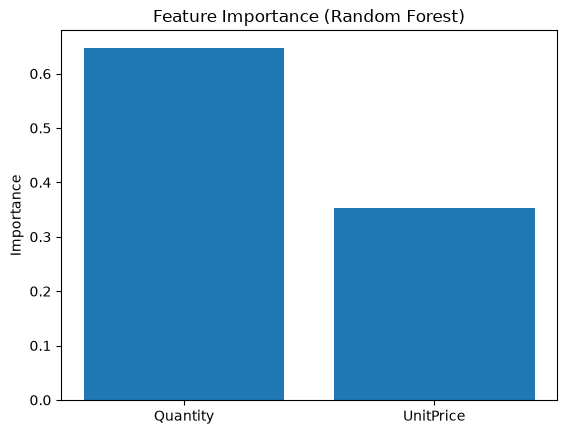

In [7]:
importances = pd.Series(forest.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)
print(importances)
plt.bar(importances.index, importances.values)
plt.ylabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.show()

## 8. Overfitting

A single deep Decision Tree can overfit — it memorizes the training data
too closely. Random Forest reduces this because it averages many trees
together, and the individual trees' mistakes tend to cancel each other
out.

In [8]:
deep_tree = DecisionTreeClassifier(random_state=1)
deep_tree.fit(X_train, y_train)
print("Single tree  -> train accuracy:", round(accuracy_score(y_train, deep_tree.predict(X_train)), 2),
      "| test accuracy:", round(accuracy_score(y_test, deep_tree.predict(X_test)), 2))
print("Random Forest -> train accuracy:", round(accuracy_score(y_train, forest.predict(X_train)), 2),
      "| test accuracy:", round(accuracy_score(y_test, forest.predict(X_test)), 2))

Single tree  -> train accuracy: 1.0 | test accuracy: 0.9
Random Forest -> train accuracy: 1.0 | test accuracy: 0.93


## 9. Advantages

- Usually more accurate than a single Decision Tree
- Much less likely to overfit
- Handles both classification and regression
- Gives useful feature importance scores

## 10. Limitations

- Slower to train and predict than a single tree (it's training many trees)
- Harder to visualize or explain than one simple tree
- Uses more memory since it stores every tree
- Still not perfect on very noisy or very high-dimensional data

## 11. Compare: Decision Tree vs Random Forest

Let's put the numbers side by side.

In [9]:
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Train Accuracy": [
        accuracy_score(y_train, deep_tree.predict(X_train)),
        accuracy_score(y_train, forest.predict(X_train)),
    ],
    "Test Accuracy": [
        accuracy_score(y_test, deep_tree.predict(X_test)),
        accuracy_score(y_test, forest.predict(X_test)),
    ],
})
comparison

,Model,Train Accuracy,Test Accuracy
0,Decision Tree,1.0,0.900
1,Random Forest,1.0,0.925


A single Decision Tree often scores very high on the training data but
drops on the test data — a sign of overfitting. Random Forest usually keeps
a smaller gap between train and test accuracy, because it's averaging many
different trees instead of trusting just one.